In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [9]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("MENTAL HEALTH SENTIMENT ANALYSIS - DATA EXPLORATION")

MENTAL HEALTH SENTIMENT ANALYSIS - DATA EXPLORATION


# 1. LOAD DATASET

In [12]:
import os
os.listdir('../data/raw')

['Combined Data.csv']

In [14]:
df = pd.read_csv('../data/raw/Combined Data.csv')

print("✓ Dataset loaded successfully")
print(df.shape)

✓ Dataset loaded successfully
(53043, 3)


In [18]:
print("\n[2/8] Analyzing basic information")

print("\n Dataset Info:")
print(df.info())

print("\n Statistical Summary:")
print(df.describe())

print("\n First 5 rows:")
print(df.head())


[2/8] Analyzing basic information

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None

 Statistical Summary:
         Unnamed: 0
count  53043.000000
mean   26521.000000
std    15312.339501
min        0.000000
25%    13260.500000
50%    26521.000000
75%    39781.500000
max    53042.000000

 First 5 rows:
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxie

# 2. MISSING VALUES

In [24]:
print("\n Checking for missing values")

missing = df.isnull().sum()
if missing.sum() > 0:
    print("\n Missing values found:")
    print(missing[missing > 0])
else:
    print(" No missing values")


 Checking for missing values

 Missing values found:
statement    362
dtype: int64


In [26]:
df['statement'] = df['statement'].fillna('')

In [28]:
before = len(df)

df = df[df['statement'].str.strip() != '']

after = len(df)

print(f" Removed {before - after} empty text rows")
print(f" Remaining samples: {after}")

 Removed 362 empty text rows
 Remaining samples: 52681


In [30]:
print(df.isnull().sum())

Unnamed: 0    0
statement     0
status        0
dtype: int64


In [32]:
print("\n Checking for missing values")

missing = df.isnull().sum()
if missing.sum() > 0:
    print("\n Missing values found:")
    print(missing[missing > 0])
else:
    print(" No missing values")


 Checking for missing values
 No missing values


# 3. TARGET VARIABLE ANALYSIS

In [41]:
import os
os.makedirs('../results/figures', exist_ok=True)


 Analyzing target variable (sentiment)

 Sentiment distribution:
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

 Percentage distribution:
  Normal: 31.02%
  Depression: 29.24%
  Suicidal: 20.22%
  Anxiety: 7.29%
  Bipolar: 5.27%
  Stress: 4.91%
  Personality disorder: 2.04%

 Class imbalance ratio: 15.17

 Saved: results/figures/01_sentiment_distribution.png


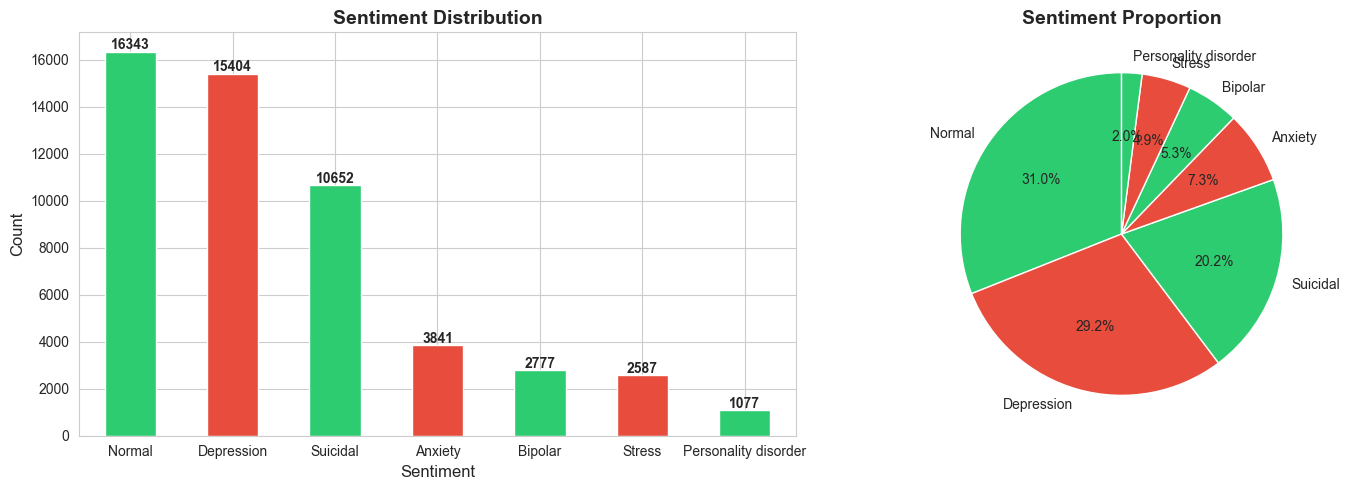

In [43]:
print("\n Analyzing target variable (sentiment)")

# The dataset has 'status' column with labels
sentiment_col = 'status'
text_col = 'statement'

print(f"\n Sentiment distribution:")
sentiment_counts = df[sentiment_col].value_counts()
print(sentiment_counts)

print(f"\n Percentage distribution:")
sentiment_pct = df[sentiment_col].value_counts(normalize=True) * 100
for label, pct in sentiment_pct.items():
    print(f"  {label}: {pct:.2f}%")

# Calculate imbalance ratio
imbalance_ratio = sentiment_counts.max() / sentiment_counts.min()
print(f"\n Class imbalance ratio: {imbalance_ratio:.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
sentiment_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(sentiment_counts):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
           colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Sentiment Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/01_sentiment_distribution.png', dpi=300, bbox_inches='tight')
print("\n Saved: results/figures/01_sentiment_distribution.png")
plt.show()

# 4. TEXT LENGTH ANALYSIS


 Analyzing text characteristics

 Text Statistics:
  Average characters: 578.71
  Average words: 113.16
  Min words: 1
  Max words: 6300

 Text length by sentiment:
                      text_length  word_count
status                                       
Anxiety                764.681073  143.837022
Bipolar                946.074901  176.200216
Depression             844.031161  168.021488
Normal                  90.244447   17.246283
Personality disorder   956.731662  179.346332
Stress                 613.545419  114.585234
Suicidal               734.967330  146.440293

 Saved: results/figures/02_text_length_analysis.png


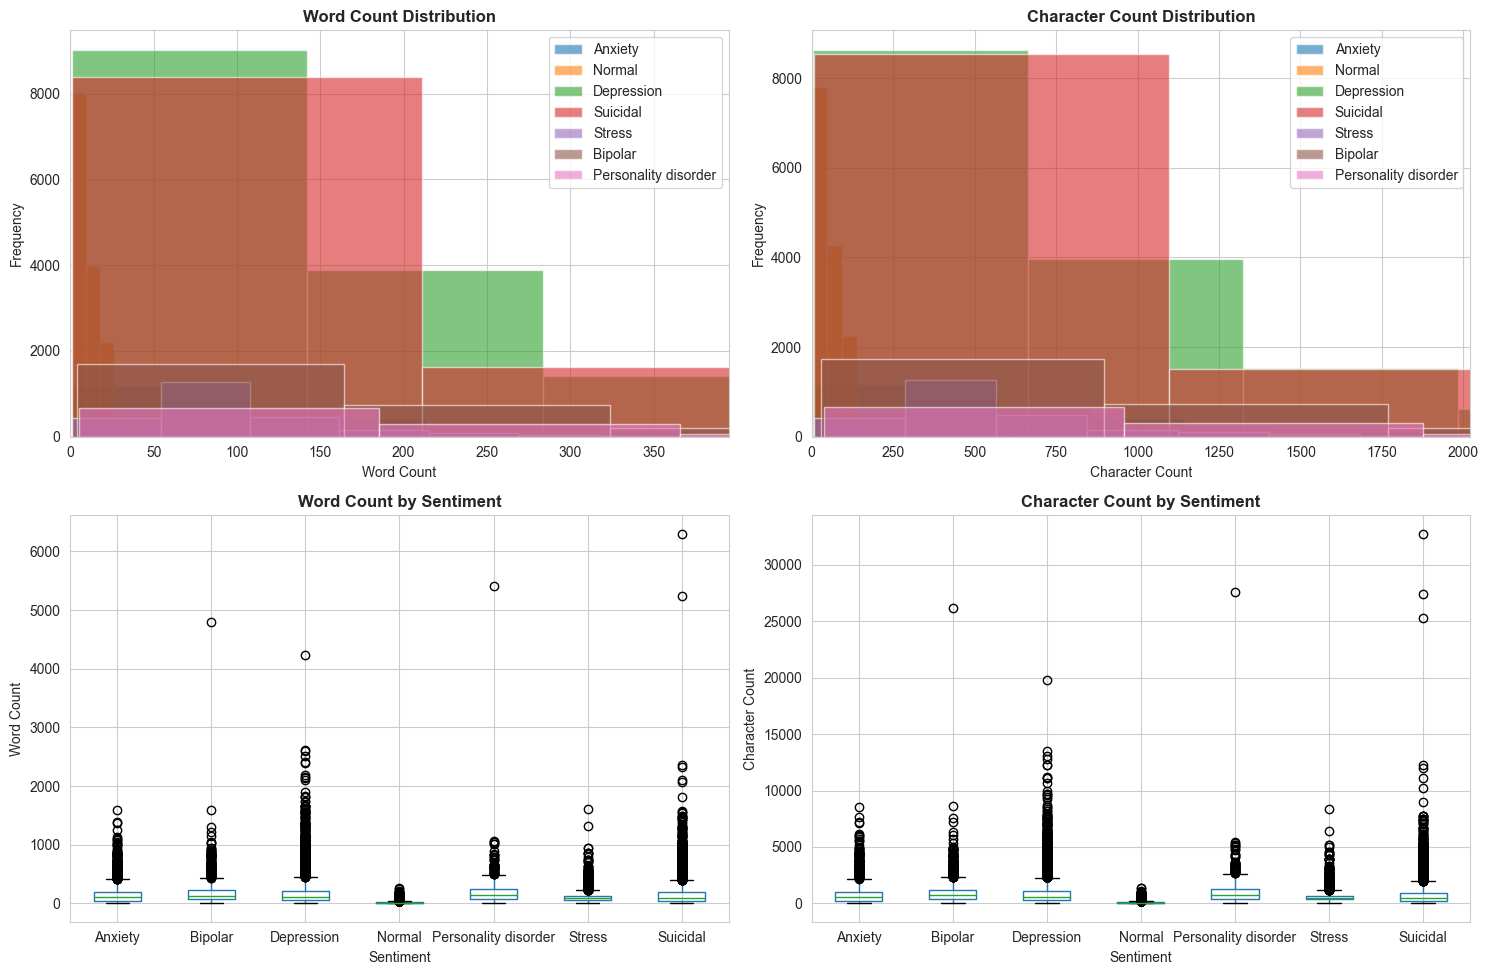

In [48]:
print("\n Analyzing text characteristics")

df['text_length'] = df[text_col].astype(str).apply(len)
df['word_count'] = df[text_col].astype(str).apply(lambda x: len(x.split()))

print(f"\n Text Statistics:")
print(f"  Average characters: {df['text_length'].mean():.2f}")
print(f"  Average words: {df['word_count'].mean():.2f}")
print(f"  Min words: {df['word_count'].min()}")
print(f"  Max words: {df['word_count'].max()}")

# Group by sentiment
print(f"\n Text length by sentiment:")
text_stats = df.groupby(sentiment_col)[['text_length', 'word_count']].mean()
print(text_stats)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Word count distribution
for sentiment in df[sentiment_col].unique():
    subset = df[df[sentiment_col] == sentiment]['word_count']
    axes[0, 0].hist(subset, alpha=0.6, label=sentiment, bins=30)
axes[0, 0].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, df['word_count'].quantile(0.95))

# Character count distribution
for sentiment in df[sentiment_col].unique():
    subset = df[df[sentiment_col] == sentiment]['text_length']
    axes[0, 1].hist(subset, alpha=0.6, label=sentiment, bins=30)
axes[0, 1].set_title('Character Count Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Character Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, df['text_length'].quantile(0.95))

# Box plots
df.boxplot(column='word_count', by=sentiment_col, ax=axes[1, 0])
axes[1, 0].set_title('Word Count by Sentiment', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sentiment')
axes[1, 0].set_ylabel('Word Count')

df.boxplot(column='text_length', by=sentiment_col, ax=axes[1, 1])
axes[1, 1].set_title('Character Count by Sentiment', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sentiment')
axes[1, 1].set_ylabel('Character Count')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../results/figures/02_text_length_analysis.png', dpi=300, bbox_inches='tight')
print("\n Saved: results/figures/02_text_length_analysis.png")
plt.show()

# 5. WORD CLOUDS


 Generating word clouds
 Saved: ../results/figures/wordclouds/Anxiety_wordcloud.png


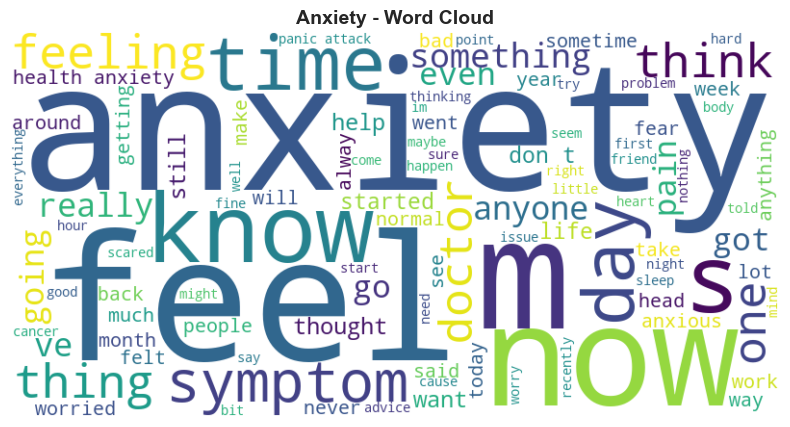

 Saved: ../results/figures/wordclouds/Normal_wordcloud.png


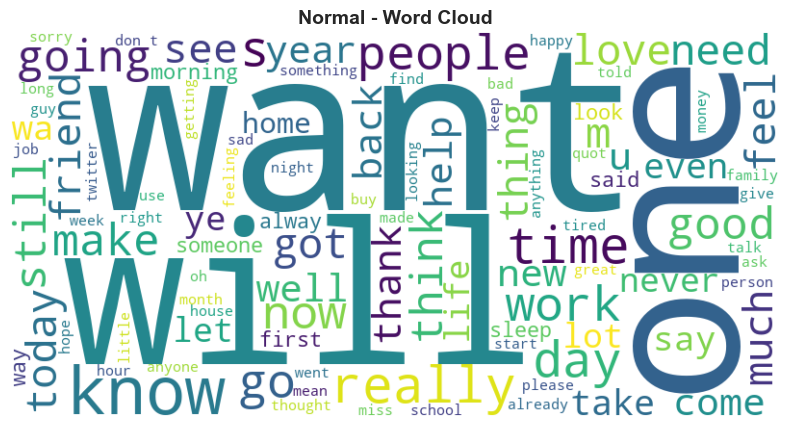

 Saved: ../results/figures/wordclouds/Depression_wordcloud.png


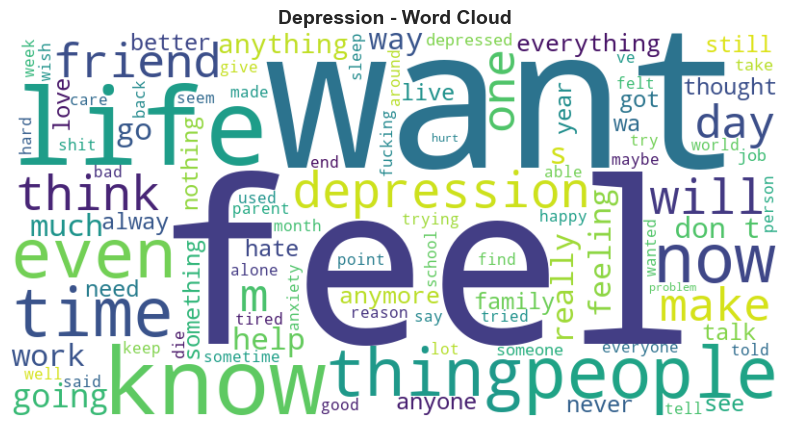

 Saved: ../results/figures/wordclouds/Suicidal_wordcloud.png


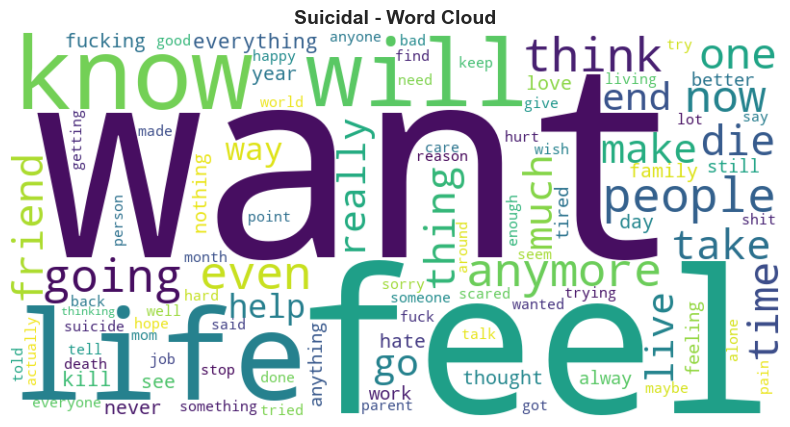

 Saved: ../results/figures/wordclouds/Stress_wordcloud.png


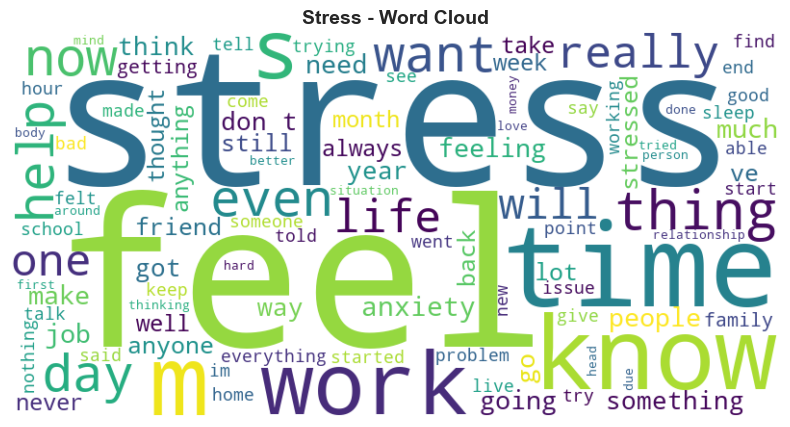

 Saved: ../results/figures/wordclouds/Bipolar_wordcloud.png


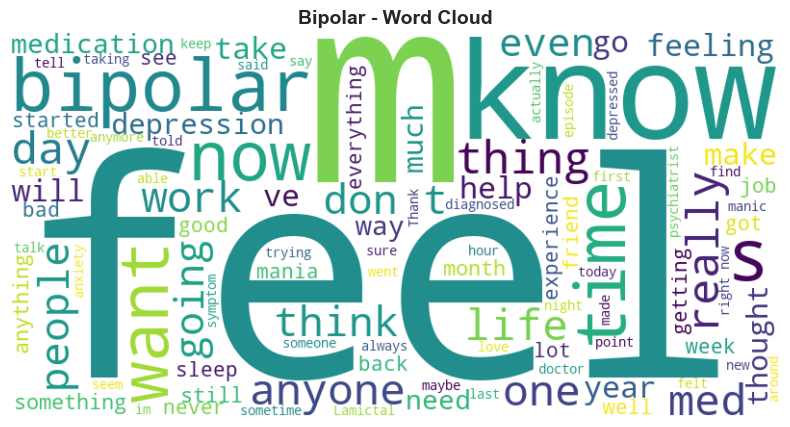

 Saved: ../results/figures/wordclouds/Personality disorder_wordcloud.png


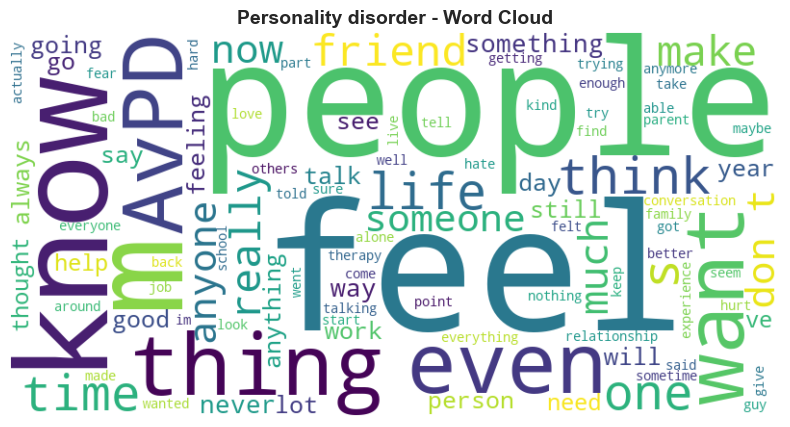

In [55]:
from wordcloud import WordCloud

print("\n Generating word clouds")

os.makedirs('../results/figures/wordclouds', exist_ok=True)

for sentiment in df[sentiment_col].unique():
    text = ' '.join(
        df[df[sentiment_col] == sentiment][text_col]
        .dropna()
        .astype(str)
    )

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{sentiment} - Word Cloud', fontsize=14, fontweight='bold')

    save_path = f'../results/figures/wordclouds/{sentiment}_wordcloud.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f" Saved: {save_path}")

    plt.show()

# 6. DATA QUALITY CHECKS

In [62]:
print("\nPerforming data quality checks")

# Duplicates
duplicates = df.duplicated(subset=[text_col]).sum()
print(f"\nDuplicate texts: {duplicates} ({duplicates/len(df)*100:.2f}%)")

# Very short texts
very_short = (df['word_count'] < 3).sum()
print(f" Very short texts (<3 words): {very_short} ({very_short/len(df)*100:.2f}%)")

# Empty texts
empty = (df[text_col].astype(str).str.strip() == '').sum()
print(f" Empty texts: {empty}")



Performing data quality checks

Duplicate texts: 1608 (3.05%)
 Very short texts (<3 words): 891 (1.69%)
 Empty texts: 0


In [66]:
df = df.drop_duplicates(subset=[text_col]).reset_index(drop=True)
print(f" Dataset size after removing duplicates: {len(df)}")

 Dataset size after removing duplicates: 51073


In [68]:
df = df[df['word_count'] >= 3].reset_index(drop=True)
print(f" Dataset size after removing short texts: {len(df)}")

 Dataset size after removing short texts: 50311


In [70]:
print("\n Final dataset check:")
print(df[[text_col, sentiment_col]].isnull().sum())
print(f" Final dataset size: {df.shape}")


 Final dataset check:
statement    0
status       0
dtype: int64
 Final dataset size: (50311, 5)


In [72]:
print("\nPerforming data quality checks")

# Duplicates
duplicates = df.duplicated(subset=[text_col]).sum()
print(f"\nDuplicate texts: {duplicates} ({duplicates/len(df)*100:.2f}%)")

# Very short texts
very_short = (df['word_count'] < 3).sum()
print(f" Very short texts (<3 words): {very_short} ({very_short/len(df)*100:.2f}%)")

# Empty texts
empty = (df[text_col].astype(str).str.strip() == '').sum()
print(f" Empty texts: {empty}")


Performing data quality checks

Duplicate texts: 0 (0.00%)
 Very short texts (<3 words): 0 (0.00%)
 Empty texts: 0


# 7. SAMPLE TEXTS

In [77]:
print("\n Displaying sample texts")

for sentiment in df[sentiment_col].unique():
    
    print(f" {sentiment.upper()} Examples:")
    samples = df[df[sentiment_col] == sentiment][text_col].sample(3)
    for i, text in enumerate(samples, 1):
        print(f"\n{i}. {text}")


 Displaying sample texts
 ANXIETY Examples:

1. Started CBT therapy a few weeks ago Hi guys 

I started my course of CBT a few weeks back and one of the first steps my therapist has told me to take is to completely stop the excessive checking I do, whether that be prodding for lumps if I feel a pain, or taking tonnes of pictures of moles thinking they’ve changed etc. The therapist was saying that there isn’t really a magic formula to stop the checking you just have to do it cold turkey.

I feel I have reduced it a fair bit since starting as I realised a lot of it was mindless, but stuff like the checking of moles is still keeping me from stopping, has anyone got any tips?

Thanks



2. Anxiety for no reason. How come?

3. I will start antidepressants tomorrow It makes me nervous. I have panic attacks every evening before going to bed. Bad ones with pounding heart, pain in chest and fear if death. Psychiatrist recommended light antidepressants. I am nervous from how they might affect m

# 8. SAVE SUMMARY

In [82]:
import os

# Create required directories if they don't exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

print(" Required directories created / already exist")

 Required directories created / already exist


In [92]:
print("EXPLORATION SUMMARY")


summary = {
    'total_samples': len(df),
    'num_classes': df[sentiment_col].nunique(),
    'class_distribution': sentiment_counts.to_dict(),
    'imbalance_ratio': float(imbalance_ratio),
    'avg_word_count': float(df['word_count'].mean()),
    'avg_text_length': float(df['text_length'].mean()),
    'duplicates': int(duplicates),
    'very_short_texts': int(very_short)
}

for key, value in summary.items():
    print(f"  {key}: {value}")

# Save for next steps
df.to_csv('../data/processed/data_with_stats.csv', index=False)
print("\n Data saved to: data/processed/data_with_stats.csv")

import json
with open('../results/metrics/exploration_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)
print(" Summary saved to: results/metrics/exploration_summary.json")


print(" DATA EXPLORATION COMPLETE!")

EXPLORATION SUMMARY
  total_samples: 50311
  num_classes: 7
  class_distribution: {'Normal': 16343, 'Depression': 15404, 'Suicidal': 10652, 'Anxiety': 3841, 'Bipolar': 2777, 'Stress': 2587, 'Personality disorder': 1077}
  imbalance_ratio: 15.17455896007428
  avg_word_count: 114.34771719902209
  avg_text_length: 583.8995647075192
  duplicates: 0
  very_short_texts: 0

 Data saved to: data/processed/data_with_stats.csv
 Summary saved to: results/metrics/exploration_summary.json
 DATA EXPLORATION COMPLETE!
